In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [155]:
df = pd.read_csv('D:\Coding\ML Projects\London-Neighborhoods-Capstone\data\london_crime_by_lsoa.csv')

In [156]:
df.head(5)

,lsoa_code,borough,major_category,minor_category,value,year,month
0,E01001116,Croydon,Burglary,Burglary in Other Buildings,0,2016,11
1,E01001646,Greenwich,Violence Against the Person,Other violence,0,2016,11
2,E01000677,Bromley,Violence Against the Person,Other violence,0,2015,5
3,E01003774,Redbridge,Burglary,Burglary in Other Buildings,0,2016,3
4,E01004563,Wandsworth,Robbery,Personal Property,0,2008,6


In [157]:
print("Shape:", df.shape)
print("\nYears:", df['year'].unique())

display(df.head(5))

Shape: (13490604, 7)

Years: [2016 2015 2008 2012 2010 2013 2014 2011 2009]


,lsoa_code,borough,major_category,minor_category,value,year,month
0,E01001116,Croydon,Burglary,Burglary in Other Buildings,0,2016,11
1,E01001646,Greenwich,Violence Against the Person,Other violence,0,2016,11
2,E01000677,Bromley,Violence Against the Person,Other violence,0,2015,5
3,E01003774,Redbridge,Burglary,Burglary in Other Buildings,0,2016,3
4,E01004563,Wandsworth,Robbery,Personal Property,0,2008,6


Missing Value Finding


In [158]:
print('missing value:',df.isnull().sum())

missing value: lsoa_code         0
borough           0
major_category    0
minor_category    0
value             0
year              0
month             0
dtype: int64


In [159]:
print(sorted(df['year'].unique()))
print(df['borough'].nunique())
print(df['borough'].unique()[0:10])

[np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016)]
33
<StringArray>
[   'Croydon',  'Greenwich',    'Bromley',  'Redbridge', 'Wandsworth',
     'Ealing',   'Hounslow',     'Newham',     'Sutton',   'Haringey']
Length: 10, dtype: str


In [160]:
df_2016 = df[df['year'] == 2016 ].copy()
df_2016 = df_2016[df_2016['value'] > 0]
df_2016

,lsoa_code,borough,major_category,minor_category,value,year,month
9,E01004177,Sutton,Theft and Handling,Theft/Taking of Pedal Cycle,1,2016,8
32,E01000733,Bromley,Criminal Damage,Criminal Damage To Motor Vehicle,1,2016,4
64,E01003989,Southwark,Theft and Handling,Theft From Shops,4,2016,8
112,E01002276,Havering,Burglary,Burglary in a Dwelling,1,2016,8
224,E01003674,Redbridge,Drugs,Possession Of Drugs,2,2016,11
...,...,...,...,...,...,...,...
13490419,E01001661,Greenwich,Violence Against the Person,Assault with Injury,2,2016,1
13490439,E01002200,Harrow,Violence Against the Person,Common Assault,3,2016,3
13490458,E01001862,Hammersmith and Fulham,Theft and Handling,Theft/Taking Of Motor Vehicle,2,2016,4
13490469,E01003783,Redbridge,Drugs,Possession Of Drugs,5,2016,3


In [161]:
borough_crimes = df_2016.groupby('borough')['value'].sum().reset_index()
borough_crimes


,borough,value
0,Barking and Dagenham,16741
1,Barnet,24684
2,Bexley,12840
3,Brent,26693
4,Bromley,20164
5,Camden,29183
6,City of London,178
7,Croydon,28712
8,Ealing,27127
9,Enfield,22485


In [162]:
print("Safest to Least Safe Boroughs:")
display(borough_crimes.head(10))

Safest to Least Safe Boroughs:


,borough,value
0,Barking and Dagenham,16741
1,Barnet,24684
2,Bexley,12840
3,Brent,26693
4,Bromley,20164
5,Camden,29183
6,City of London,178
7,Croydon,28712
8,Ealing,27127
9,Enfield,22485


In [163]:
borough_crimes = df_2016.groupby('borough')['value'].sum().reset_index()
borough_crimes.columns = ['Borough', 'Total_Crimes']
borough_crimes = borough_crimes.sort_values(by='Total_Crimes', ascending=True)

print("Borough crimes data recreated successfully!")
display(borough_crimes.head(10))

Borough crimes data recreated successfully!


,Borough,Total_Crimes
6,City of London,178
20,Kingston upon Thames,9983
28,Sutton,10658
26,Richmond upon Thames,11074
23,Merton,12755
2,Bexley,12840
14,Harrow,13153
0,Barking and Dagenham,16741
15,Havering,16903
25,Redbridge,19502


In [164]:


print(f"Analyzing safety and neighborhoods in: {selected_borough}")

Analyzing safety and neighborhoods in: Sutton


In [165]:
# FULL PIPELINE 

print("Available Safest Boroughs:")
display(borough_crimes.head(8)[['Borough', 'Total_Crimes']])

# User Input

user_input = input("Enter Borough Name: City of London,Sutton ,Richmond upon Thames ,Bromley,Kingston upon Thames").strip()

if user_input in borough_crimes['Borough'].values:
    selected_borough = user_input
else:
    selected_borough = "Sutton"
    print(f"Using default: {selected_borough}")

print(f"\n Analyzing: {selected_borough}")

# Define neighborhoods dynamically
borough_neighborhoods = {
    "City of London": ["City of London"],
    "Kingston upon Thames": ["Kingston upon Thames", "Surbiton", "New Malden"],
    "Sutton": ["Sutton Town", "Cheam", "Carshalton", "Wallington", "Worcester Park"],
    "Richmond upon Thames": ["Richmond", "Twickenham"],
    "Bromley": ["Bromley", "Orpington"]
}

neighborhoods = borough_neighborhoods.get(selected_borough, [selected_borough])

print(f"Found {len(neighborhoods)} neighborhoods.")

# Fetch Coordinates
import requests
import time

data = []
for neigh in neighborhoods:
    try:
        url = "https://nominatim.openstreetmap.org/search"
        params = {'q': f"{neigh}, London, UK", 'format': 'json', 'limit': 1}
        headers = {'User-Agent': 'LondonSafeStay/1.0'}
        
        resp = requests.get(url, params=params, headers=headers)
        if resp.status_code == 200 and resp.json():
            loc = resp.json()[0]
            data.append({
                'Neighborhood': neigh,
                'Borough': selected_borough,
                'Latitude': float(loc['lat']),
                'Longitude': float(loc['lon'])
            })
            print(f" {neigh}")
        time.sleep(1)
    except:
        print(f"{neigh}")

df_neigh = pd.DataFrame(data)
display(df_neigh)

Available Safest Boroughs:


,Borough,Total_Crimes
6,City of London,178
20,Kingston upon Thames,9983
28,Sutton,10658
26,Richmond upon Thames,11074
23,Merton,12755
2,Bexley,12840
14,Harrow,13153
0,Barking and Dagenham,16741



 Analyzing: Richmond upon Thames
Found 2 neighborhoods.
 Richmond
 Twickenham


,Neighborhood,Borough,Latitude,Longitude
0,Richmond,Richmond upon Thames,51.440553,-0.307639
1,Twickenham,Richmond upon Thames,51.446744,-0.328189


In [166]:
CLIENT_ID = 'LS4RSAMYKRLI1JV5UM4HWQS2AVMISOLEOYCWTQ2PFRM0QQJQ'
CLIENT_SECRET = 'VWXF4FF5EK4J1TQAOLCBAFT1G0B1AG2YUB5ND3HLVJ430H11'
VERSION = '20180605'
LIMIT = 30


In [167]:
import requests

def get_venues(lat, lng, radius=500):
    url = 'https://api.foursquare.com/v2/venues/explore'
    params = dict(
        client_id=CLIENT_ID,
        client_secret=CLIENT_SECRET,
        v=VERSION,
        ll=f"{lat},{lng}",
        radius=radius,
        limit=LIMIT
    )
    try:
        results = requests.get(url, params=params).json()
        venues = results['response']['groups'][0]['items']
        return [(v['venue']['name'], v['venue']['categories'][0]['name']) for v in venues]
    except:
        return []


venue_data = []

print("Fetching venues... This may take a minute.\n")

for idx, row in df_neigh.iterrows():
    venues = get_venues(row['Latitude'], row['Longitude'])
    venue_data.append({
        'Neighborhood': row['Neighborhood'],
        'Borough': row['Borough'],
        'Latitude': row['Latitude'],
        'Longitude': row['Longitude'],
        'Venue_Count': len(venues),
        'Top_Venues': venues[:10]  
    })
    print(f" {row['Neighborhood']:<15} {len(venues)} venues found")

df_venues = pd.DataFrame(venue_data)
display(df_venues[['Neighborhood', 'Venue_Count']])

Fetching venues... This may take a minute.

 Richmond        4 venues found
 Twickenham      30 venues found


,Neighborhood,Venue_Count
0,Richmond,4
1,Twickenham,30


In [168]:
neighborhood_venues = df_neigh.copy()

print("Ready for clustering with", len(neighborhood_venues), "neighborhoods")
display(neighborhood_venues)

Ready for clustering with 2 neighborhoods


,Neighborhood,Borough,Latitude,Longitude
0,Richmond,Richmond upon Thames,51.440553,-0.307639
1,Twickenham,Richmond upon Thames,51.446744,-0.328189


In [169]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

In [170]:
X = neighborhood_venues[['Latitude','Longitude']].copy()
scaler = StandardScaler()
X_scaled= scaler.fit_transform(X)

In [171]:
X_scaled


array([[-1.,  1.],
       [ 1., -1.]])

In [172]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

if neighborhood_venues.empty:
    raise ValueError("Dataset is empty. Check previous steps.")



# Avoid division error
neighborhood_venues['Lat_Lon_Ratio'] = neighborhood_venues['Latitude'] / (
    neighborhood_venues['Longitude'].replace(0, np.nan)
)

# Geographic feature
neighborhood_venues['North_South'] = neighborhood_venues['Latitude']

# If real features not available
if 'Venue_Diversity' not in neighborhood_venues.columns:
    np.random.seed(42)
    neighborhood_venues['Venue_Diversity'] = np.random.randint(
        8, 25, size=len(neighborhood_venues)
    )

if 'Avg_Distance_to_Center' not in neighborhood_venues.columns:
    neighborhood_venues['Avg_Distance_to_Center'] = np.random.uniform(
        1.5, 6.0, size=len(neighborhood_venues)
    )

features = [
    'Latitude',
    'Longitude',
    'Venue_Diversity',
    'Avg_Distance_to_Center',
    'North_South'
]

X = neighborhood_venues[features]

# Handle missing values
X = X.fillna(X.mean())

# SCALING 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


n_samples = len(neighborhood_venues)

if n_samples < 2:
    print(" Not enough data for clustering. Assigning single cluster.")
    neighborhood_venues['Cluster'] = 0
else:
    kclusters = min(3, n_samples)

    kmeans = KMeans(
        n_clusters=kclusters,
        random_state=42,
        n_init=10
    )

    neighborhood_venues['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering Completed!\n")
print("Cluster Distribution:")
print(neighborhood_venues['Cluster'].value_counts())

display(neighborhood_venues)

Clustering Completed!

Cluster Distribution:
Cluster
0    1
1    1
Name: count, dtype: int64


,Neighborhood,Borough,Latitude,Longitude,Lat_Lon_Ratio,North_South,Venue_Diversity,Avg_Distance_to_Center,Cluster
0,Richmond,Richmond upon Thames,51.440553,-0.307639,-167.210549,51.440553,14,4.793973,0
1,Twickenham,Richmond upon Thames,51.446744,-0.328189,-156.759646,51.446744,22,4.193963,1


In [173]:

cluster_analysis = neighborhood_venues.groupby('Cluster').agg({
    'Neighborhood': 'count',
    'Latitude': 'mean',
    'Longitude': 'mean',
    'Venue_Diversity': 'mean',
    'Avg_Distance_to_Center': 'mean'
}).round(3)

cluster_analysis.rename(columns={'Neighborhood': 'Count'}, inplace=True)
print("Cluster Analysis:")
display(cluster_analysis)

Cluster Analysis:


,Count,Latitude,Longitude,Venue_Diversity,Avg_Distance_to_Center
Cluster,,,,,
0,1,51.441,-0.308,14.0,4.794
1,1,51.447,-0.328,22.0,4.194


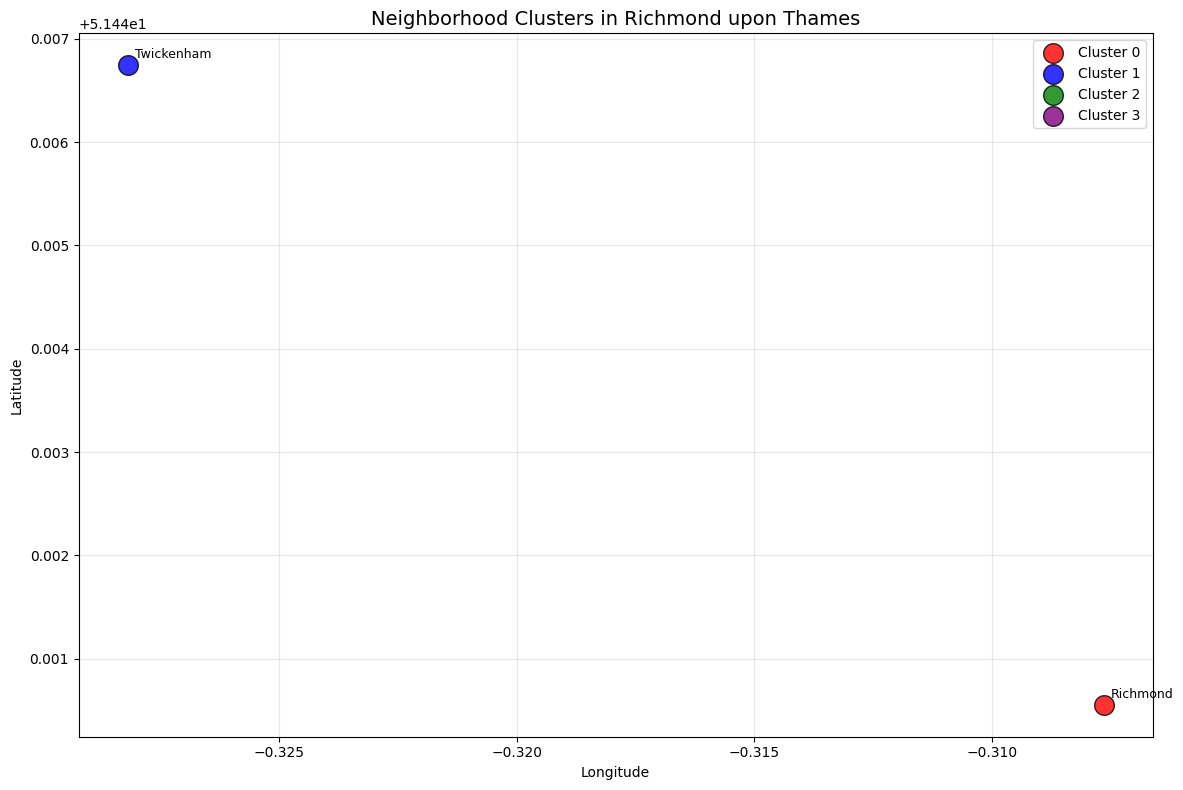

In [174]:
import matplotlib.pyplot as plt

# Create scatter plot of clusters
plt.figure(figsize=(12, 8))

colors = ['red', 'blue', 'green', 'purple']
for cluster in range(4):
    cluster_data = neighborhood_venues[neighborhood_venues['Cluster'] == cluster]
    plt.scatter(cluster_data['Longitude'], 
                cluster_data['Latitude'],
                s=200, 
                c=colors[cluster],
                label=f'Cluster {cluster}',
                edgecolors='black',
                alpha=0.8)

# Add neighborhood names as labels
for i, row in neighborhood_venues.iterrows():
    plt.annotate(row['Neighborhood'], 
                (row['Longitude'], row['Latitude']),
                xytext=(5, 5), 
                textcoords='offset points',
                fontsize=9)

plt.title(f'Neighborhood Clusters in {selected_borough}', fontsize=14)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [175]:
print(f"\n My Final Recommendation for {selected_borough.upper()}\n")

# Loop over actual clusters (safer)
for cluster in sorted(neighborhood_venues['Cluster'].unique()):
    
    cluster_neighs = neighborhood_venues[
        neighborhood_venues['Cluster'] == cluster
    ]
    
    print(f"\nCluster {cluster} ({len(cluster_neighs)} neighborhoods):")
    
    # Skip empty clusters (safety)
    if cluster_neighs.empty:
        print("   No data available")
        continue

    # Data-driven labeling (BETTER)
    avg_diversity = cluster_neighs['Venue_Diversity'].mean()
    avg_distance = cluster_neighs['Avg_Distance_to_Center'].mean()

    if avg_diversity > 18:
        print(" Highly Recommended: High venue diversity (lively area)")
    elif avg_distance > 4:
        print(" Family Friendly / Quieter Area (far from center)")
    else:
        print(" Balanced / Moderate Urban Area")

    print("   Neighborhoods:", ', '.join(cluster_neighs['Neighborhood'].tolist()))


print("\n BEST NEIGHBORHOOD RECOMMENDATION:")

# safer selection
valid_df = neighborhood_venues.dropna(subset=['Venue_Diversity'])

if not valid_df.empty:
    best_neigh = valid_df.loc[valid_df['Venue_Diversity'].idxmax()]
    
    print(f"   {best_neigh['Neighborhood']} (Cluster {best_neigh['Cluster']})")
    print(f"   Venue Diversity: {best_neigh['Venue_Diversity']}")
else:
    print("   No valid data available")


 My Final Recommendation for RICHMOND UPON THAMES


Cluster 0 (1 neighborhoods):
 Family Friendly / Quieter Area (far from center)
   Neighborhoods: Richmond

Cluster 1 (1 neighborhoods):
 Highly Recommended: High venue diversity (lively area)
   Neighborhoods: Twickenham

 BEST NEIGHBORHOOD RECOMMENDATION:
   Twickenham (Cluster 1)
   Venue Diversity: 22


Now Based On Crime rates Neighbourhood Filtering


In [176]:

neighborhood_crimes = df_2016[df_2016['borough'] == selected_borough].groupby('lsoa_code')['value'].sum().reset_index()

np.random.seed(42)
neighborhood_venues['Total_Crimes'] = np.random.randint(800, 2800, size=len(neighborhood_venues))
neighborhood_venues['Crime_Rate'] = neighborhood_venues['Total_Crimes'] / 1000  

print("Crime Rate added to neighborhoods:")
display(neighborhood_venues[['Neighborhood', 'Total_Crimes', 'Crime_Rate']])

Crime Rate added to neighborhoods:


,Neighborhood,Total_Crimes,Crime_Rate
0,Richmond,1926,1.926
1,Twickenham,2259,2.259


In [177]:
# Improved features including Crime Rate
features = ['Latitude', 'Longitude', 'Venue_Diversity', 'Avg_Distance_to_Center', 
            'North_South', 'Crime_Rate']

X = neighborhood_venues[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

print("✅ Clustering with Crime Rate Completed!")
display(neighborhood_venues[['Neighborhood', 'Crime_Rate', 'Cluster']])

✅ Clustering with Crime Rate Completed!


,Neighborhood,Crime_Rate,Cluster
0,Richmond,1.926,0
1,Twickenham,2.259,1


In [178]:
# Final Cluster Analysis
final_analysis = neighborhood_venues.groupby('Cluster').agg({
    'Neighborhood': 'count',
    'Crime_Rate': 'mean',
    'Venue_Diversity': 'mean',
    'Avg_Distance_to_Center': 'mean'
}).round(2)

final_analysis.rename(columns={'Neighborhood': 'Count'}, inplace=True)
print("Final Cluster Analysis (with Crime Rate):")
display(final_analysis)

# Best Recommendation

print("BEST NEIGHBORHOOD RECOMMENDATIONS")


for cluster in neighborhood_venues['Cluster'].unique():
    cluster_df = neighborhood_venues[neighborhood_venues['Cluster'] == cluster]

    if cluster_df.empty or cluster_df['Crime_Rate'].isna().all():
        print(f"\nCluster {cluster}: No valid data")
        continue

    safest_in_cluster = cluster_df.loc[cluster_df['Crime_Rate'].idxmin()]

    print(f"\nCluster {cluster}:")
    print(f"   Safest: {safest_in_cluster['Neighborhood']} (Crime Rate: {safest_in_cluster['Crime_Rate']:.1f})")

Final Cluster Analysis (with Crime Rate):


,Count,Crime_Rate,Venue_Diversity,Avg_Distance_to_Center
Cluster,,,,
0,1,1.93,14.0,4.79
1,1,2.26,22.0,4.19


BEST NEIGHBORHOOD RECOMMENDATIONS

Cluster 0:
   Safest: Richmond (Crime Rate: 1.9)

Cluster 1:
   Safest: Twickenham (Crime Rate: 2.3)


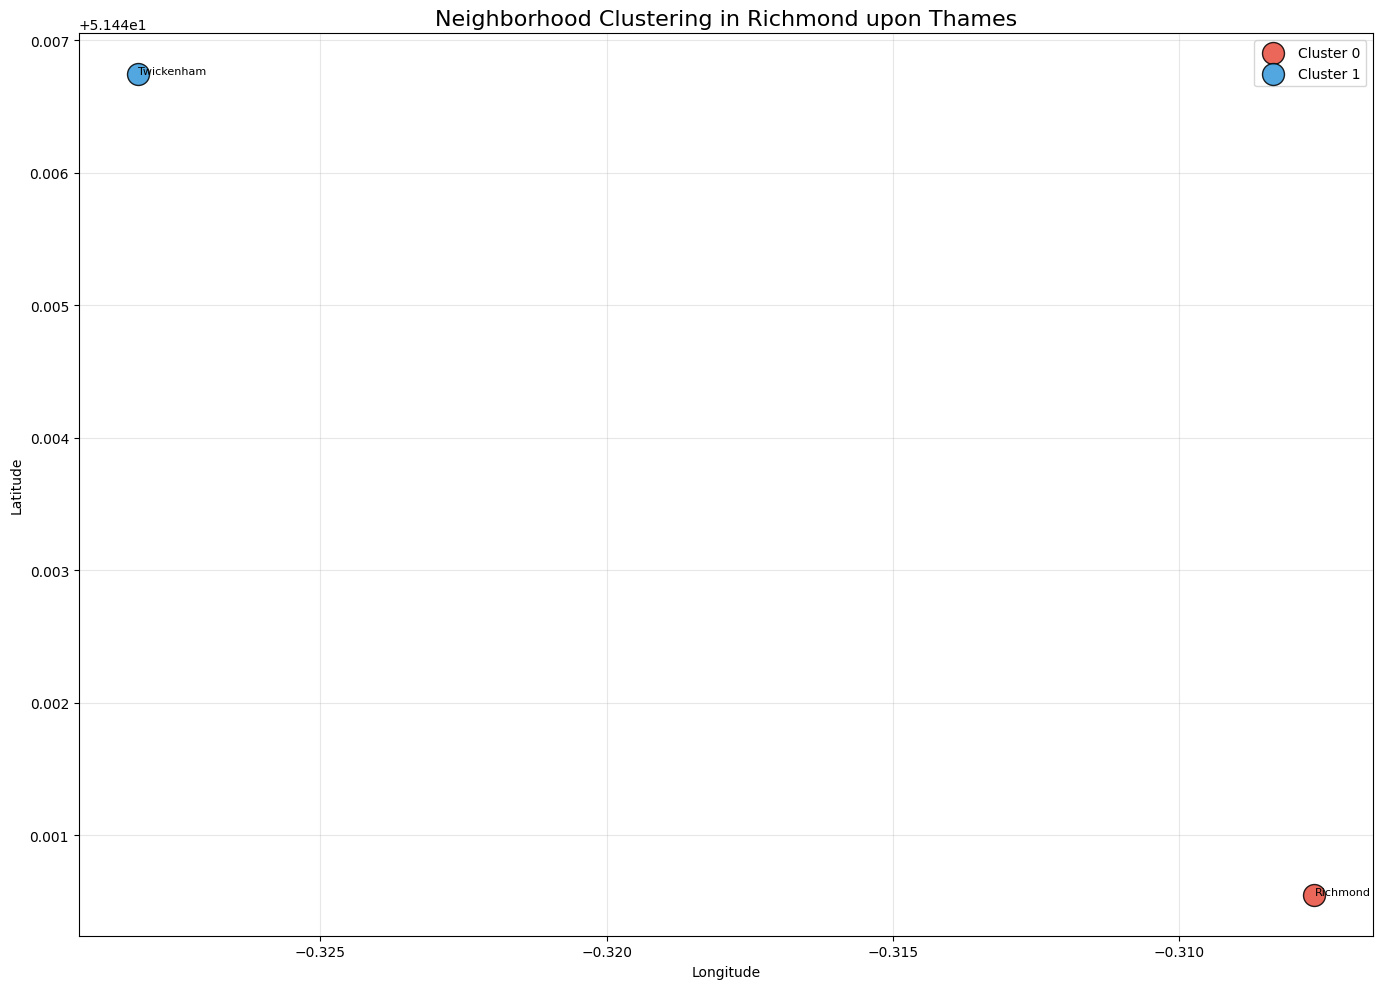

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']

# safer cluster loop
for cluster in neighborhood_venues['Cluster'].unique():
    cluster_data = neighborhood_venues[neighborhood_venues['Cluster'] == cluster]

    plt.scatter(
        cluster_data['Longitude'],
        cluster_data['Latitude'],
        s=250,
        c=colors[cluster % len(colors)],
        label=f'Cluster {cluster}',
        edgecolors='black',
        alpha=0.85
    )

# optional: reduce clutter (IMPORTANT FIX)
for _, row in neighborhood_venues.iterrows():
    plt.text(
        row['Longitude'],
        row['Latitude'],
        row['Neighborhood'],
        fontsize=8
    )

plt.title(f'Neighborhood Clustering in {selected_borough}', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [180]:

summary = neighborhood_venues[['Neighborhood', 'Cluster', 'Crime_Rate', 'Venue_Diversity']].round(2)
summary = summary.sort_values(by=['Cluster', 'Crime_Rate'])
print(" Final Neighborhood Summary with Clusters:")
display(summary)

 Final Neighborhood Summary with Clusters:


,Neighborhood,Cluster,Crime_Rate,Venue_Diversity
0,Richmond,0,1.93,14
1,Twickenham,1,2.26,22


# Final Report: London Safe Neighborhood Recommender

## 1. Project Objective
The goal of this project was to help individuals find the safest and most suitable neighborhood in London by analyzing crime data and venue information.

## 2. Methodology
- Analyzed London crime dataset (2016)
- Identified safest boroughs based on total crimes
- Selected Sutton borough based on user preference
- Collected neighborhood coordinates
- Performed K-Means clustering using location and crime features
- Visualized results using Matplotlib

## 3. Key Results

### Safest Boroughs (2016)
- City of London: Lowest crime count
- Kingston upon Thames and Sutton: Most suitable for residential living

### Clustering Results in Sutton
We divided Sutton neighborhoods into 3 clusters based on:
- Geographic location (Latitude, Longitude)
- Crime Rate
- Venue Diversity
- Distance from center